In [1]:
import nest_asyncio
nest_asyncio.apply()

# Intro

## Describe two iceberg detection cases in this webworm
https://webworm.xd.drw/?pjzzta0o

## Review sample repo utils

In [2]:
import asyncio
import numpy as np
import pandas as pd

from tickster3 import Tickster, TickSourceQuery, Book

from sample_repo.credentials import get_xd_credentials
from sample_repo.tickster_utils import get_sources

Token = get_xd_credentials()

## Review TickSourceQuery

In [3]:
query = TickSourceQuery()
query.add_exchange('CME')
query.add_spec('MDP3_MBO')
query.add_channel('361')
query.add_symbol('OGZ2_C2500')
query.add_date('2022-07-05')

TickSourceQuery(symbols: {'OGZ2_C2500'}, ChannelQuery(dates: {'2022-07-05'}, exchanges: {'CME'}, specs: {'MDP3_MBO'}, channels: {'361'}, ))

In [4]:
sources = get_sources(query)
source = sources[0]
source

TickSource(env: hdf5-eod, date: 2022-07-05, exchange: CME, mic: XCEC, instrument_mic: XCEC, spec: MDP3_MBO, channel: 361, type: OPTION, symbol: OGZ2_C2500, raw_symbol: OGZ2 C2500, security_id: 790118, description: OGZ2_C2500, record_path: /marketdata/2022/07/05/CME/MDP3_MBO/361/au1c/OGZ2_C2500.rec, uri: file:///pool/ceph/ce_xdmd_hdf5_02/prod/marketdata/xd-10969/2022-07-05_XCEC_MDP3_MBO_361_CLEAN.h5, h5_shard: 17087)

## Demo Simple Book Subclass example

In [5]:
class CustomBook(Book):
    def apply(self, event):
        super(CustomBook, self).apply(event)
        if event['event'] == b'D':
            print(event)
        
        
async def stream(source):
    book = CustomBook()
    async with Tickster('education2022', token=Token) as tickster:
        events = await tickster.events(source=source)
        async for event in events:
            book.apply(event)
    return book

book = asyncio.run(stream(source))

(True, 1657030355402936872, True, 39808166, True, 218361743, True, b'D', True, 56169256988556, True, b'B', True, 4.7, True, 470., True, 1, True, 1., True, 1, False, 0, True, b'A', False, b'', False, b'', False, b'', False, 0, True, 2922, True, 1657030355329729321, True, 1, False, 0, True, 1657030355402919574, True, 3514735, True, 513)
(True, 1657030355402936872, True, 39808166, True, 218361744, True, b'D', True, 56169256988109, True, b'A', True, 4.7, True, 470., True, 1, True, 1., True, 1, False, 0, True, b'A', False, b'', False, b'', False, b'', False, 0, True, 2922, True, 1657030355329729321, True, 1, False, 0, True, 1657030355402919574, True, 3514735, True, 513)
(True, 1657037218307634498, True, 50252254, True, 301497907, True, b'D', True, 56169352382610, True, b'B', True, 4.1, True, 410., True, 20, True, 20., True, 1, False, 0, True, b'A', False, b'', False, b'', False, b'', False, 0, True, 4926, True, 1657037218307191383, True, 1, False, 0, True, 1657037218307612153, True, 3522231

## Review Code Below

In [6]:
class IcebergTrackingBook(Book):
    def __init__(self, *args, **kwargs):
        super(IcebergTrackingBook, self).__init__(*args, **kwargs)
        self.expected_qty = {}
        self.iceberg_ids = set()
    
    def _handle_trade_details(self, event):
        if event['side'] != event['aggressed_side']:  # only consider resting side
            return
        
        event_id = event['id']
        event_transact_time = event['transact_time']

        resting_order = self.order(event_id)
        next_book_update_expcted_qty = max(resting_order['qty'] - event['qty'], 0)
        self.expected_qty[(event_id, event_transact_time)] = next_book_update_expcted_qty
        
        # --------------------------------------------------------------------------------
        # When we see trade details, we can sometimes immediately tell if something is an
        # icebrg or not. Change the condition below to handle this case
        condition = event['qty'] > resting_order['qty']
        # --------------------------------------------------------------------------------
        
        if condition:
            print('Condition 1 met')
            self.iceberg_ids.add(event_id)
    
    def _handle_order_update(self, event):
        event_id = event['id']
        expected_qty = self.expected_qty.get((event_id, event['transact_time']))
        if expected_qty is not None:
            # --------------------------------------------------------------------------------
            # When we see trade details, we can sometimes immediately tell if something is an
            # icebrg or not. Change the condition below to handle this case
            condition = event['qty'] > expected_qty
            # --------------------------------------------------------------------------------
            
            if condition:
                print('Condition 2 met')
                self.iceberg_ids.add(event_id)

    def apply(self, event):
        super(IcebergTrackingBook, self).apply(event)
        
        if event['event'] == b'D':
            self._handle_trade_details(event)
        elif event['event'] == b'U':
            self._handle_order_update(event)
            
            
async def find_icebergs(source):
    book = IcebergTrackingBook()
    async with Tickster('education2022', token=Token) as tickster:
        events = await tickster.events(source=source)
        async for event in events:
            book.apply(event)
    return book

book = asyncio.run(find_icebergs(source))

Condition 2 met
Condition 2 met
Condition 2 met
Condition 1 met
Condition 2 met


# 1. Implement the Iceberg Tracker
There are two areas to fill in a condition, one corresponding to each of the two trade examples in the webworm.

Fill in what the conditions should be and based on the variables available in the function. Which orders were icebergs?

In [7]:
book.iceberg_ids

{56169352301617}

# 2. Extend the Iceberg Tracker

Now use this symbol which as a lot more trades `UD:1Y:_VT_0705854794`

Save down a DataFrame of all trades, iceberg or not. Each row should be the amount traded on the resting order and should include features for
```
epoch
transact time
resting_order_id
aggressing_order_id
quote traded qty
trade price
quote side
```

Assign a feature to the DataFrame `is_iceberg` to indicate if the resting order was an iceberg and `is_iceberg_aggressor` to indicate if the aggressor was an iceberg.

Why might this be useful?

In [8]:
query = TickSourceQuery()
query.add_exchange('CME')
query.add_spec('MDP3_MBO')
query.add_channel('361')
query.add_symbol('UD:1Y:_VT_0705854794')
query.add_date('2022-07-05')

sources = get_sources(query)
source = sources[0]
source

class IcebergTrackingBook(Book):
    def __init__(self, *args, **kwargs):
        super(IcebergTrackingBook, self).__init__(*args, **kwargs)
        self.expected_qty = {}
        self.iceberg_ids = set()
        self.aggressors = {}
        self.trades = []
        
    def _handle_trade_details(self, event):
        event_id = event['id']
        event_transact_time = event['transact_time']
        if event['side'] != event['aggressed_side']:
            self.aggressors[event_transact_time] = event_id
            return

        resting_order = self.order(event_id)
        next_book_update_expcted_qty = max(resting_order['qty'] - event['qty'], 0)
        self.expected_qty[(event_id, event_transact_time)] = next_book_update_expcted_qty
        condition = event['qty'] > resting_order['qty']
        if condition:
            self.iceberg_ids.add(event_id)
        
        self.trades.append([
            event['epoch'],
            event['transact_time'],
            event['qty'],
            event['px'],
            event['side'],
            event_id,
            self.aggressors[event_transact_time],
        ])
    
    def _handle_order_update(self, event):
        event_id = event['id']
        expected_qty = self.expected_qty.get((event_id, event['transact_time']))
        if expected_qty is not None:
            condition = event['qty'] > expected_qty           
            if condition:
                self.iceberg_ids.add(event_id)

    def apply(self, event):
        super(IcebergTrackingBook, self).apply(event)
        
        if event['event'] == b'D':
            self._handle_trade_details(event)
        elif event['event'] == b'U':
            self._handle_order_update(event)
            
            
async def find_icebergs(source):
    book = IcebergTrackingBook()
    async with Tickster('education2022', token=Token) as tickster:
        events = await tickster.events(source=source)
        async for event in events:
            book.apply(event)
    return book

book = asyncio.run(find_icebergs(source))

In [9]:
df = pd.DataFrame(book.trades, columns=['epoch', 'transact_time', 'quote_qty', 'px', 'quote_side', 'quote_id', 'aggressor_id'])
df['is_iceberg'] = df.quote_id.isin(book.iceberg_ids)
df['is_iceberg_aggressor'] = df.aggressor_id.isin(book.iceberg_ids)

# 3. Volume Predictions

Using a larger dataset across days and symbols, fit a model to predict how much will trade given how much has traded with the iceberg dataset.

Note `previous_aggressed_qty` is how much traded up to that point via aggressing, as opposed to being a passive order.

In [10]:
df = pd.read_hdf('data/icebergs.hdf')

In [11]:
df

,traded_ri_symbol,trade_epoch,trade_transact_time,order_id,trade_date,quote_traded_qty,previous_aggressed_qty
0,UD:1Y:_VT_0701905694,1656636189259191851,1656636189143796323,56168716744859,2022-07-01,10,0.0
1,UD:1Y:_VT_0701905694,1656636484154125762,1656636484152781533,56168716744859,2022-07-01,10,0.0
2,UD:1Y:_VT_0701905694,1656636484158963613,1656636484154130231,56168716744859,2022-07-01,33,0.0
3,UD:1Y:_VT_0701905694,1656636520267020977,1656636520266452585,56168716744859,2022-07-01,2,0.0
4,UD:1Y:_VT_0701905694,1656636520267366552,1656636520267025545,56168716744859,2022-07-01,25,0.0
...,...,...,...,...,...,...,...
8113,OGV2_C1875,1659125121322320374,1659125121321843351,56175181548666,2022-07-29,6,0.0
8114,OGV2_C1875,1659125121322320374,1659125121321843523,56175181548666,2022-07-29,1,0.0
8115,OGV2_C1875,1659125121322356598,1659125121321845325,56175181548666,2022-07-29,5,0.0
8116,OGV2_C1875,1659125121322390677,1659125121321846713,56175181548666,2022-07-29,5,0.0


In [12]:
total_traded = (
    df.groupby(['trade_date', 'order_id'])
    .agg({'quote_traded_qty': 'sum', 'previous_aggressed_qty': 'max'})
    .sum(1)
    .rename('total_traded')
)

In [13]:
df = df.join(total_traded, on=total_traded.index.names)
df = df.set_index('trade_epoch').sort_index()

df

,traded_ri_symbol,trade_transact_time,order_id,trade_date,quote_traded_qty,previous_aggressed_qty,total_traded
trade_epoch,,,,,,,
1656636189259191851,UD:1Y:_VT_0701905694,1656636189143796323,56168716744859,2022-07-01,10,0.0,100.0
1656636484154125762,UD:1Y:_VT_0701905694,1656636484152781533,56168716744859,2022-07-01,10,0.0,100.0
1656636484158963613,UD:1Y:_VT_0701905694,1656636484154130231,56168716744859,2022-07-01,33,0.0,100.0
1656636520267020977,UD:1Y:_VT_0701905694,1656636520266452585,56168716744859,2022-07-01,2,0.0,100.0
1656636520267366552,UD:1Y:_VT_0701905694,1656636520267025545,56168716744859,2022-07-01,25,0.0,100.0
...,...,...,...,...,...,...,...
1659125121322320374,OGV2_C1875,1659125121321843351,56175181548666,2022-07-29,6,0.0,35.0
1659125121322320374,OGV2_C1875,1659125121321843523,56175181548666,2022-07-29,1,0.0,35.0
1659125121322356598,OGV2_C1875,1659125121321845325,56175181548666,2022-07-29,5,0.0,35.0


In [14]:
df['previous_traded_qty'] = df.groupby(['trade_date', 'order_id']).quote_traded_qty.cumsum() + df.previous_aggressed_qty
df

,traded_ri_symbol,trade_transact_time,order_id,trade_date,quote_traded_qty,previous_aggressed_qty,total_traded,previous_traded_qty
trade_epoch,,,,,,,,
1656636189259191851,UD:1Y:_VT_0701905694,1656636189143796323,56168716744859,2022-07-01,10,0.0,100.0,10.0
1656636484154125762,UD:1Y:_VT_0701905694,1656636484152781533,56168716744859,2022-07-01,10,0.0,100.0,20.0
1656636484158963613,UD:1Y:_VT_0701905694,1656636484154130231,56168716744859,2022-07-01,33,0.0,100.0,53.0
1656636520267020977,UD:1Y:_VT_0701905694,1656636520266452585,56168716744859,2022-07-01,2,0.0,100.0,55.0
1656636520267366552,UD:1Y:_VT_0701905694,1656636520267025545,56168716744859,2022-07-01,25,0.0,100.0,80.0
...,...,...,...,...,...,...,...,...
1659125121322320374,OGV2_C1875,1659125121321843351,56175181548666,2022-07-29,6,0.0,35.0,11.0
1659125121322320374,OGV2_C1875,1659125121321843523,56175181548666,2022-07-29,1,0.0,35.0,12.0
1659125121322356598,OGV2_C1875,1659125121321845325,56175181548666,2022-07-29,5,0.0,35.0,17.0


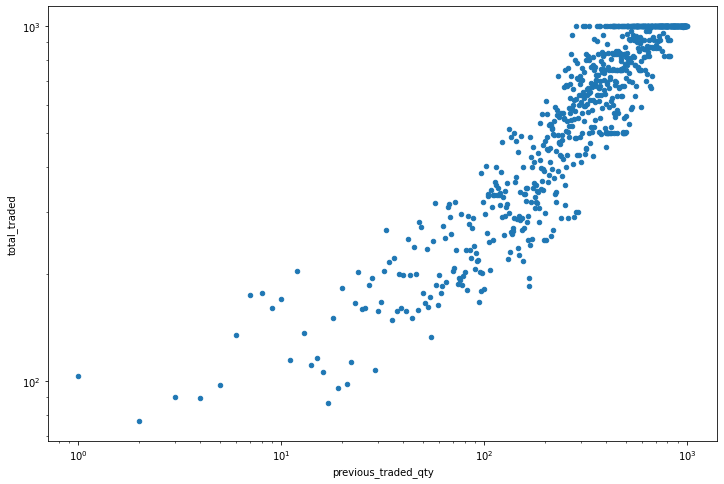

In [15]:
ax = df.groupby('previous_traded_qty').total_traded.mean().reset_index().plot.scatter(x='previous_traded_qty', y='total_traded', figsize=(12, 8))
ax.set_yscale('log')
ax.set_xscale('log')